# MAMMAL Model Inference

Perform inference with MAMMAL models that were fine‑tuned on the WDR91-ASMS and PGK2-DEL datasets.

## Steps
0. Configuration — edit paths here
1. Preview input data
2. Load tokenizer
3. Load model
4. Build DataLoader
5. Run inference
6. Inspect predictions
7. Evaluate (if labels available)
8. Enrichment metrics (Precision@K / EF@K)
9. Top hits

In [ ]:
def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False
IN_COLAB = in_colab()
print(f"{IN_COLAB=}")  

IN_COLAB=False


In [ ]:
if IN_COLAB:
    !pip install biomed-multi-alignment

## 0. Configuration

**Edit the paths below before running.**

In [ ]:
import os
import torch
import numpy as np
import pandas as pd

run_on_wdr91 = False
model_name = "mammal" # "mmelon"
USER = os.getenv("USER")


if run_on_wdr91:
    # MODEL_PATH = "/proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mammal_fixed/last.ckpt"
    MODEL_PATH = "michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.wdr91_asms"
    DATA_NAME = "wdr91"
    if IN_COLAB:
        DATA_PATH = "/content/wdr91_test.csv"
    else:
        DATA_PATH = "/proj/ligand_ai/datasets_manager/processed/splits/wdr91_ASMS_train_val_v1/test.csv"        
else:
    DATA_NAME = "pgk2"
    # MODEL_PATH = "/proj/ligand_ai/models/PGK2_DEL_cdd_to_creative_mammal/last-v2.ckpt"
    MODEL_PATH = "michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.pgk2_del_cdd"
    if IN_COLAB:
        DATA_PATH = "/content/del_creative.csv"
    else:
        DATA_PATH = "/proj/ligand_ai/datasets_manager/processed/splits/PGK2_DEL_cdd_to_creative/test.csv"

if IN_COLAB:
    OUTPUT_DIR_PATH = f"/content/results"
else:
    OUTPUT_DIR_PATH = f"/proj/ligand_ai/users/{USER}/results" 

OUTPUT_PATH = os.path.join(OUTPUT_DIR_PATH, f"{DATA_NAME}_{model_name}_predictions.csv")
SMILES_COLUMN = "smiles"
LABEL_COLUMN  = "label"  

# Inference device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── VALIDATION ─────────────────────────────────────────────────────────────────
# assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
assert os.path.exists(DATA_PATH),  f"Data not found:  {DATA_PATH}"
os.makedirs(os.path.dirname(OUTPUT_PATH) or ".", exist_ok=True)

print(f"Model : {MODEL_PATH}")
print(f"Data  : {DATA_PATH}")
print(f"Output: {OUTPUT_PATH}")
print(f"Device: {DEVICE}")

Model : michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.pgk2_del_cdd
Data  : /proj/ligand_ai/datasets_manager/processed/splits/PGK2_DEL_cdd_to_creative/test.csv
Output: /proj/ligand_ai/users/ozery/results/pgk2_mammal_predictions.csv
Device: cuda


## 1. Preview Input Data

In [ ]:
input_df = pd.read_csv(DATA_PATH)
input_df["sample_id"] = input_df.index

print(f"\nLabel distribution:")
print(input_df[LABEL_COLUMN].value_counts().sort_index())

display(input_df)


Label distribution:
label
0    13280
1     1468
Name: count, dtype: int64


,smiles,label,sample_id
0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(C...,0,0
1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)...,0,1
2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)...,0,2
3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)N...,0,3
4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4...,1,4
...,...,...,...
14743,CNC(=O)C[C@@H](Cc1ccccc1)n1c(-c2ccc3c(c2)oc(=O...,0,14743
14744,CNC(=O)C[C@H](c1ccccc1)n1c(C2CCCCC2C)nc2cc(CNC...,0,14744
14745,CO[C@@]1(C)CCN(C(=O)[C@H]2CC[C@H](CN(CC(=O)O)C...,0,14745
14746,Cc1ccc(N)cc1CN(C)C(=O)C1(c2cccc(C(=O)NCCCn3ccn...,1,14746


## 2. Load Tokenizer

In [ ]:
from fuse.data.tokenizers.modular_tokenizer.op import ModularTokenizerOp
tokenizer_op = ModularTokenizerOp.from_pretrained(MODEL_PATH)
print("Tokenizer loaded.")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500], your vo

## 3. Load Model

In [ ]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # 0=all, 1=filter INFO, 2=filter WARNING, 3=filter ERROR
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="google.protobuf")

from mammal.model import Mammal

#TODO: use save_pretrained 
model = Mammal.from_pretrained(MODEL_PATH)

Path doesn't exist. Will try to download from hf hub. pretrained_model_name_or_path='michalozeryflato/biomed.omics.bl.sm.ma-ted-458m.pgk2_del_cdd'


Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Attempting to load model from dir: pretrained_model_name_or_path='/u/ozery/.cache/huggingface/hub/models--michalozeryflato--biomed.omics.bl.sm.ma-ted-458m.pgk2_del_cdd/snapshots/d2e98b8307a3aeed4c76be92f36bc3e8fa5ca0f3'


## 4. Build DataLoader

In [ ]:
from torch.utils.data import DataLoader, Dataset
from fuse.data.utils.collates import CollateDefault
from mammal.keys import *
from functools import partial

In [ ]:
from mammal.keys import *

def prepare_prompts(
        sample_dict: dict,
        tokenizer_op: ModularTokenizerOp,
        *,
        sequence_key: str = "data.smiles",
        label_key: str  = "data.label",
        drug_max_seq_length: int = 300,
        encoder_input_max_seq_len: int | None = 320,
        labels_max_seq_len: int | None = 4,
    ) -> dict:

        drug_sequence = sample_dict[sequence_key]
    
        sample_dict[ENCODER_INPUTS_STR] = (
            f"<@TOKENIZER-TYPE=SMILES><SENTINEL_ID_0>"
            f"<MOLECULAR_ENTITY><MOLECULAR_ENTITY_SMALL_MOLECULE>"
            f"<@TOKENIZER-TYPE=SMILES@MAX-LEN={drug_max_seq_length}>"
            f"<SEQUENCE_NATURAL_START>{drug_sequence}<SEQUENCE_NATURAL_END><EOS>"
        )
        
        # Tokenize encoder input
        tokenizer_op(
            sample_dict=sample_dict,
            key_in=ENCODER_INPUTS_STR,
            key_out_tokens_ids=ENCODER_INPUTS_TOKENS,
            key_out_attention_mask=ENCODER_INPUTS_ATTENTION_MASK,
            max_seq_len=encoder_input_max_seq_len,
        )
        for k in (ENCODER_INPUTS_TOKENS, ENCODER_INPUTS_ATTENTION_MASK):
            sample_dict[k] = torch.tensor(sample_dict[k])
        
        # Process labels if available (for training/validation)
        if label_key in sample_dict:
            label = sample_dict[label_key]

            pad_id = tokenizer_op.get_token_id("<PAD>")
            ignore_token_value = -100
            
            # Format labels
            sample_dict[LABELS_STR] = (
                f"<@TOKENIZER-TYPE=SMILES><SENTINEL_ID_0><{label}><EOS>"
            )
            tokenizer_op(
                sample_dict=sample_dict,
                key_in=LABELS_STR,
                key_out_tokens_ids=LABELS_TOKENS,
                key_out_attention_mask=LABELS_ATTENTION_MASK,
                max_seq_len=labels_max_seq_len,
            )

            for k in (LABELS_TOKENS, LABELS_ATTENTION_MASK):
                sample_dict[k] = torch.tensor(sample_dict[k])
            
            
            # Replace pad tokens with ignore value
            sample_dict[LABELS_TOKENS][
                (sample_dict[LABELS_TOKENS][..., None] == torch.tensor(pad_id))
                .any(-1)
                .nonzero()
            ] = ignore_token_value

            # Format decoder input
            sample_dict[DECODER_INPUTS_STR] = (
                f"<@TOKENIZER-TYPE=SMILES><DECODER_START><SENTINEL_ID_0><{label}><EOS>"
            )
            tokenizer_op(
                sample_dict=sample_dict,
                key_in=DECODER_INPUTS_STR,
                key_out_tokens_ids=DECODER_INPUTS_TOKENS,
                key_out_attention_mask=DECODER_INPUTS_ATTENTION_MASK,
                max_seq_len=labels_max_seq_len,
            )

            for k in (DECODER_INPUTS_TOKENS, DECODER_INPUTS_ATTENTION_MASK):
                sample_dict[k] = torch.tensor(sample_dict[k])

        return sample_dict

In [ ]:
import pandas as pd
from torch.utils.data import Dataset


class SMILESDataset(Dataset):
    def __init__(
        self,
        filepath: str,
        tokenizer_op: ModularTokenizerOp,
        smiles_column: str = SMILES_COLUMN,
        label_column: str = LABEL_COLUMN, 
    ) -> None:
        """Initialize dataset by loading data from CSV file."""

        self.tokenizer_op = tokenizer_op
        
        # Load data file
        df = pd.read_csv(filepath)
        
        # Convert to lists for fast access (avoids DataFrame indexing overhead)
        self.sample_ids = df.index.tolist()
        self.smiles = df[smiles_column].tolist()
        if label_column in df:
            self.labels = df[label_column].tolist()
        else:
            self.labels = None
            
    def __len__(self) -> int:
        return len(self.smiles)
    
    def __getitem__(self, idx: int) -> dict:
        sample_dict = {
            "data.sample_id": self.sample_ids[idx],
            "data.smiles": self.smiles[idx],
           
        }
        if self.labels is not None:
            sample_dict["data.label"] = self.labels[idx]
        sample_dict = prepare_prompts(sample_dict, 
                                                    tokenizer_op=self.tokenizer_op)
        return sample_dict

    def __len__(self) -> int:
        return len(self.smiles)

In [ ]:
smiles_dataset = SMILESDataset(
        filepath=DATA_PATH,
        tokenizer_op=tokenizer_op,
    )

In [ ]:
def build_dataloader(
    dataset: Dataset,
    batch_size: int = 128,
    num_workers: int = 0,
) -> DataLoader:
    # Optional: For cropping padding tokens after collate (to avoid unnecessary computation on padding)
    pad_token_id = tokenizer_op.get_token_id("<PAD>")
    special_handlers = {
        ENCODER_INPUTS_TOKENS: partial(
            CollateDefault.crop_padding, pad_token_id=pad_token_id
        ),
        ENCODER_INPUTS_ATTENTION_MASK: partial(
            CollateDefault.crop_padding, pad_token_id=False
        ),
    }

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=CollateDefault(special_handlers_keys=special_handlers),
        shuffle=False,
        num_workers=num_workers,
    )
    return loader

In [ ]:
dataloader = build_dataloader(smiles_dataset)

In [ ]:
# first_batch = next(iter(dataloader))
# for k, v in first_batch.items():
#     print(f"{k}: {type(v)} {len(v)}")

data.query.decoder_input.with_placeholders: <class 'list'> 128
data.decoder_input_attention_mask: <class 'torch.Tensor'> 128
data.query.labels.with_placeholders: <class 'list'> 128
data.labels_token_ids: <class 'torch.Tensor'> 128
data.query.labels.per_meta_part_encoding: <class 'list'> 128
data.query.decoder_input.per_meta_part_encoding: <class 'list'> 128
data.decoder_input_token_ids: <class 'torch.Tensor'> 128
data.encoder_input_token_ids: <class 'torch.Tensor'> 128
data.query.decoder_input: <class 'list'> 128
data.query.encoder_input: <class 'list'> 128
data.query.encoder_input.per_meta_part_encoding: <class 'list'> 128
data.encoder_input_attention_mask: <class 'torch.Tensor'> 128
data.label: <class 'torch.Tensor'> 128
data.sample_id: <class 'list'> 128
data.smiles: <class 'list'> 128
data.query.labels: <class 'list'> 128
data.labels_attention_mask: <class 'torch.Tensor'> 128
data.query.encoder_input.with_placeholders: <class 'list'> 128


## 5. Run Inference

In [ ]:
from tqdm import tqdm
def run_inference(
    model: Mammal,
    dataloader: DataLoader,
    tokenizer_op: ModularTokenizerOp,
    device: str = "cpu",
    classification_position: int = 1,
) -> pd.DataFrame:

    model.eval()
    model = model.to(device)

    negative_token_id = tokenizer_op.get_token_id("<0>")
    positive_token_id = tokenizer_op.get_token_id("<1>")

    results: dict[str, list] = {
        "sample_id": [],
        "predicted_label": [],
        "prediction_score": [],
    }
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Inference"):
            batch_size = batch[ENCODER_INPUTS_TOKENS].shape[0]

            for k in (ENCODER_INPUTS_TOKENS, ENCODER_INPUTS_ATTENTION_MASK):
                batch[k] = batch[k].to(device)  
            batch_out = model.generate(
                batch,
                output_scores=True,
                return_dict_in_generate=True,
                max_new_tokens=5,
            )

            decoder_scores = batch_out[SCORES]  # (B, seq_len, vocab)
      
            for i in range(batch_size):
                sample_id = batch["data.sample_id"][i]
                decoder_output_scores = decoder_scores[i].cpu().numpy()  # (seq_len, vocab)
                
                # normalize the scores of the positive and negative tokens to get a probability for the positive class
                neg_score = decoder_output_scores[classification_position, negative_token_id]
                pos_score = decoder_output_scores[classification_position, positive_token_id]
                score = pos_score / (pos_score + neg_score + 1e-8)  # probability of positive class
                
                predicted_label = 1 if score >= 0.5 else 0

                results["sample_id"].append(sample_id)
                results["predicted_label"].append(predicted_label)
                results["prediction_score"].append(score)

    return pd.DataFrame(results)

In [ ]:
%%time
predictions_df = run_inference(
    model=model,
    dataloader=dataloader,
    tokenizer_op=tokenizer_op,
    device=DEVICE,
)

Inference: 100%|███████████████████████████████████████████████████████████████| 116/116 [00:22<00:00,  5.23it/s]

CPU times: user 21.5 s, sys: 726 ms, total: 22.3 s
Wall time: 22.3 s


In [ ]:
predictions_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved {len(predictions_df)} predictions to: {OUTPUT_PATH}")


Saved 14748 predictions to: /proj/ligand_ai/users/ozery/results/pgk2_mammal_predictions.csv


In [ ]:
predictions_df = input_df.merge(predictions_df, on="sample_id")
predictions_df = predictions_df.rename(columns={LABEL_COLUMN:"true_label"})

## 6. Inspect Predictions

In [ ]:
print(f"Shape: {predictions_df.shape}")
print(f"\nPredicted label distribution:")
print(predictions_df["predicted_label"].value_counts().sort_index())
print(f"\nScore statistics:")
print(predictions_df["prediction_score"].describe())
display(predictions_df)

Shape: (14748, 5)

Predicted label distribution:
predicted_label
0    13462
1     1286
Name: count, dtype: int64

Score statistics:
count    1.474800e+04
mean     8.735234e-02
std      2.806232e-01
min      9.136210e-08
25%      3.696008e-07
50%      5.529329e-07
75%      1.327393e-06
max      9.999967e-01
Name: prediction_score, dtype: float64


,smiles,true_label,sample_id,predicted_label,prediction_score
0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(C...,0,0,0,1.143947e-06
1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)...,0,1,0,2.283712e-06
2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)...,0,2,0,9.135719e-07
3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)N...,0,3,0,2.026409e-06
4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4...,1,4,1,9.999827e-01
...,...,...,...,...,...
14743,CNC(=O)C[C@@H](Cc1ccccc1)n1c(-c2ccc3c(c2)oc(=O...,0,14743,0,2.563990e-07
14744,CNC(=O)C[C@H](c1ccccc1)n1c(C2CCCCC2C)nc2cc(CNC...,0,14744,0,1.781489e-07
14745,CO[C@@]1(C)CCN(C(=O)[C@H]2CC[C@H](CN(CC(=O)O)C...,0,14745,0,6.753845e-07
14746,Cc1ccc(N)cc1CN(C)C(=O)C1(c2cccc(C(=O)NCCCn3ccn...,1,14746,0,8.178201e-07


## 7. Evaluate (if labels available)

CLASSIFICATION METRICS
Accuracy  : 0.9759
Precision : 0.9323
Recall    : 0.8168
F1 Score  : 0.8707
ROC AUC   : 0.9550
PR AUC    : 0.8680


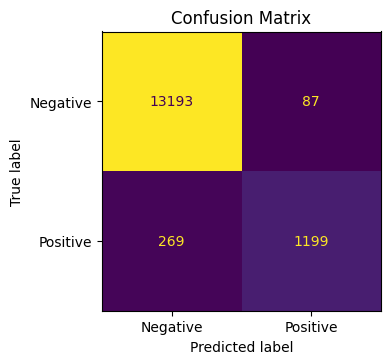

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

valid   = predictions_df[predictions_df["true_label"].notna()].copy()
y_true  = valid["true_label"].astype(int)
y_pred  = valid["predicted_label"].astype(int)
y_score = valid["prediction_score"].astype(float)

print("=" * 50)
print("CLASSIFICATION METRICS")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_true, y_score):.4f}")
print(f"PR AUC    : {average_precision_score(y_true, y_score):.4f}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. Enrichment Metrics

Precision@K and Enrichment Factor (EF@K).

**EF@K** = Precision@K / hit_prevalence  
where hit_prevalence = fraction of positives in the full dataset.

In [ ]:
def calculate_enrichment_metrics(
    y_true,
    y_scores,
    top_k_values: list[int] | None = None,
) -> dict:
    if top_k_values is None:
        top_k_values = [10, 50, 100, 500, 1000, 2000]

    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    sorted_indices = np.argsort(y_scores)[::-1]
    sorted_labels = y_true[sorted_indices]

    hit_prevalence = np.sum(y_true) / len(y_true)

    enrichment: dict = {}
    for k in top_k_values:
        if k <= len(sorted_labels):
            top_k_labels = sorted_labels[:k]
            precision_at_k = np.sum(top_k_labels) / k
            enrichment[f"Precision@{k}"] = precision_at_k
            enrichment[f"EF@{k}"] = (
                precision_at_k / hit_prevalence if hit_prevalence > 0 else np.nan
            )
        else:
            enrichment[f"Precision@{k}"] = np.nan
            enrichment[f"EF@{k}"] = np.nan

    return enrichment

In [ ]:
n_total = len(valid)
top_k_values = sorted({k for k in [10, 50, 100, 500, 1000, 2000] if k <= n_total})
if n_total not in top_k_values:
    top_k_values.append(n_total)

enrichment = calculate_enrichment_metrics(
    y_true.values, y_score.values, top_k_values=top_k_values
)

n_positives = int(y_true.sum())
hit_prev    = n_positives / n_total

print("=" * 60)
print("ENRICHMENT METRICS")
print("=" * 60)
print(f"Dataset : {n_total} compounds  |  Positives: {n_positives}  |  Hit rate: {hit_prev:.2%}")
print()
print(f"{'K':>8}  {'Precision@K':>12}  {'EF@K':>8}  {'Hits in top-K':>14}")
print("-" * 50)
for k in top_k_values:
    prec = enrichment.get(f"Precision@{k}", np.nan)
    ef   = enrichment.get(f"EF@{k}",        np.nan)
    hits = int(round(prec * k)) if not np.isnan(prec) else "N/A"
    print(f"{k:>8}  {prec:>12.4f}  {ef:>8.2f}  {hits:>14}")
print("=" * 60)

ef_rows = [
    {
        "K":             k,
        "Precision@K":   enrichment.get(f"Precision@{k}", np.nan),
        "EF@K":          enrichment.get(f"EF@{k}",        np.nan),
        "Hits_in_top_K": int(round(enrichment.get(f"Precision@{k}", 0) * k)),
    }
    for k in top_k_values
]
ef_df = pd.DataFrame(ef_rows)
ef_df

ENRICHMENT METRICS
Dataset : 14748 compounds  |  Positives: 1468  |  Hit rate: 9.95%

       K   Precision@K      EF@K   Hits in top-K
--------------------------------------------------
      10        0.9000      9.04               9
      50        0.8800      8.84              44
     100        0.9400      9.44              94
     500        0.9780      9.83             489
    1000        0.9870      9.92             987
    2000        0.6235      6.26            1247
   14748        0.0995      1.00            1468


,K,Precision@K,EF@K,Hits_in_top_K
0,10,0.900000,9.041689,9
1,50,0.880000,8.840763,44
2,100,0.940000,9.443542,94
3,500,0.978000,9.825302,489
4,1000,0.987000,9.915719,987
5,2000,0.623500,6.263881,1247
6,14748,0.099539,1.000000,1468


## 9. Top Hits

In [ ]:
top_k = 20
top_predictions_df = (
    predictions_df
    .sort_values("prediction_score", ascending=False)
    .head(top_k)
    .reset_index(drop=True)
)

n_pos = (top_predictions_df["true_label"] == 1).sum()
print(f"Top {top_k} predicted positives (out of {n_pos} total predicted positives):")
display(top_predictions_df[["sample_id", SMILES_COLUMN, "prediction_score", "true_label"]])

Top 20 predicted positives (out of 19 total predicted positives):


,sample_id,smiles,prediction_score,true_label
0,5179,CNC(=O)CC1CCN(C(=O)[C@H](Cc2ccc(-c3cnc4[nH]c(O...,0.999997,0
1,1142,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)...,0.999996,1
2,8421,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)...,0.999996,1
3,6980,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)...,0.999995,1
4,13722,CNC(=O)C1CCC(NC(=O)c2cc(NCc3ccnc4[nH]ccc34)ccc...,0.999994,1
5,2127,CNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)C[C@@H]1...,0.999993,1
6,11791,CNC(=O)C1CCC(NC(=O)c2cc(NCc3ccncc3)ccc2Sc2ccc(...,0.999993,1
7,8871,CNC(=O)C1CCC(NC(=O)c2[nH]c3ccc(OC)cc3c2Cc2c(CN...,0.999993,1
8,9050,CNC(=O)CCNC(=O)C(Oc1ccc(Cc2c[nH]c3cc(Br)cc(NCc...,0.999993,1
9,14043,CNC(=O)CN1CCN(C(=O)c2ccc(F)c(Cc3c[nH]c4cc(Cl)c...,0.999992,1
